<a href="https://colab.research.google.com/github/nbhide8/Bhargava-Lab-Project/blob/main/Bhargava_Lab_Project_Model_and_Evaluation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TIL Classification — Model Training

**Project:** Bhargava Lab intro pathology-AI project. Classify tumor-infiltrating lymphocyte (TIL) presence/absence in 64x64 H&E patches from TCGA-LUAD, comparing three approaches:
1. A CNN trained from scratch
2. An ImageNet-pretrained ResNet, fine-tuned on this data
3. Frozen embeddings from a pathology foundation model + linear probe

**Data:** 101,242 patches from 50 patients, built and validated in a separate data-processing notebook (downloaded via IDC, extracted and aligned to Stony Brook TIL maps, saved as one `.npz` per patient on Drive). This notebook only loads that already-built dataset — no DICOM/WSI handling here.

**Plan:** build and verify the simplest piece first (load data → patient-level split → from-scratch CNN → train → eval), then add the ResNet and foundation-model comparisons once that's confirmed working.

### Setup and load data

Mount Drive and load every patient's saved patches into memory. 101k patches at 64×64×3 uint8 is only ~1.2GB, so this is safe to hold in RAM directly rather than streaming from disk.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import glob, os
import numpy as np

save_dir = '/content/drive/MyDrive/TCGA_LUAD_DATA/scaled_patches'
files = sorted(glob.glob(os.path.join(save_dir, '*.npz')))
print(f"Found {len(files)} patient files")

all_patches, all_labels, patient_ids = [], [], []
for f in files:
    patient_id = os.path.basename(f).replace('.npz', '')
    d = np.load(f)
    all_patches.append(d['patches'])
    all_labels.append(d['labels'])
    patient_ids.append(np.full(len(d['labels']), patient_id))

all_patches = np.concatenate(all_patches)
all_labels = np.concatenate(all_labels)
patient_ids = np.concatenate(patient_ids)

print(f"Total patches: {len(all_labels)}, shape: {all_patches.shape}")
print(f"Overall positive rate: {all_labels.mean():.3f}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found 50 patient files
Total patches: 101242, shape: (101242, 64, 64, 3)
Overall positive rate: 0.618


### Patient-level train/test split

Split by **patient**, not by patch — patches from the same slide share staining batch, scanner, and biology, so a patch-level split would let a model leak information across train/test. 40 patients for training, 10 held out for testing.

In [ ]:
unique_patients = sorted(set(patient_ids))
rng = np.random.default_rng(0)
shuffled = rng.permutation(unique_patients)
train_patients, test_patients = set(shuffled[:40]), set(shuffled[40:])

train_mask = np.isin(patient_ids, list(train_patients))
test_mask = np.isin(patient_ids, list(test_patients))

print(f"Train: {train_mask.sum()} patches from {len(train_patients)} patients, "
      f"positive rate {all_labels[train_mask].mean():.3f}")
print(f"Test: {test_mask.sum()} patches from {len(test_patients)} patients, "
      f"positive rate {all_labels[test_mask].mean():.3f}")

Train: 80529 patches from 40 patients, positive rate 0.614
Test: 20713 patches from 10 patients, positive rate 0.633


# Model 1: from-scratch CNN

Same architecture pattern validated earlier: a small 3-conv-layer CNN, trained with class-weighted loss to account for the ~62/38 imbalance (weighting the loss rather than discarding data to force balance).

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class PatchDataset(Dataset):
    def __init__(self, patches, labels):
        self.patches = patches
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.patches[idx]).float().permute(2, 0, 1) / 255.0
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

train_ds = PatchDataset(all_patches[train_mask], all_labels[train_mask])
test_ds = PatchDataset(all_patches[test_mask], all_labels[test_mask])
train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=128, shuffle=False, num_workers=2)

# Weight the loss to counteract the ~62/38 imbalance, computed from the TRAIN split only.
n_pos = all_labels[train_mask].sum()
n_neg = len(all_labels[train_mask]) - n_pos
pos_weight = torch.tensor(n_neg / n_pos)
print(f"pos_weight: {pos_weight.item():.3f}")

class TinyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),   # 64 -> 32
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 32 -> 16
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, 1)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.flatten(1)).squeeze(1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)
model = TinyCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))

pos_weight: 0.628
Device: cuda


### Train the CNN

More epochs than the validation run (10 vs. 3) since this is real data, not a plumbing check — with a loss curve to confirm it's actually converging, not just decreasing for one epoch by chance.

In [ ]:
import matplotlib.pyplot as plt

checkpoint_dir = '/content/drive/MyDrive/TCGA_LUAD_DATA/model_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
cnn_checkpoint_path = os.path.join(checkpoint_dir, 'cnn.pt')

if os.path.exists(cnn_checkpoint_path):
    print(f"Found existing checkpoint at {cnn_checkpoint_path} - loading instead of retraining")
    model.load_state_dict(torch.load(cnn_checkpoint_path, map_location=device))
    epoch_losses = []  # no new training happened, so there's nothing to plot below
else:
    epoch_losses = []
    for epoch in range(10):
        model.train()
        total_loss = 0
        for imgs, labels_batch in train_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device)
            optimizer.zero_grad()
            logits = model(imgs)
            loss = criterion(logits, labels_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * imgs.size(0)
        avg_loss = total_loss / len(train_ds)
        epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}: train loss = {avg_loss:.4f}")

    torch.save(model.state_dict(), cnn_checkpoint_path)
    print(f"Saved checkpoint to {cnn_checkpoint_path}")

if epoch_losses:
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(range(1, len(epoch_losses) + 1), epoch_losses, marker='o', color='#4C72B0')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train loss')
    plt.tight_layout()
    plt.savefig('/content/cnn_loss_curve.png', dpi=80)
    plt.show()
else:
    print("(No loss curve to show - loaded from checkpoint, no training occurred this run)")

Found existing checkpoint at /content/drive/MyDrive/TCGA_LUAD_DATA/model_checkpoints/cnn.pt - loading instead of retraining
(No loss curve to show - loaded from checkpoint, no training occurred this run)


### Evaluate on held-out patients

Reporting accuracy against the majority-class baseline, plus precision/recall/F1 per class — with real class imbalance (62/38), raw accuracy alone can be misleading.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

model.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for imgs, labels_batch in test_loader:
        imgs = imgs.to(device)
        logits = model(imgs)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu()
        all_preds.append(preds)
        all_true.append(labels_batch)

all_preds = torch.cat(all_preds).numpy()
all_true = torch.cat(all_true).numpy()

accuracy = (all_preds == all_true).mean()
majority_baseline = max(all_true.mean(), 1 - all_true.mean())

print(f"Test accuracy: {accuracy:.4f}")
print(f"Majority-class baseline: {majority_baseline:.4f}")
print()
print(classification_report(all_true, all_preds, target_names=['absent', 'present']))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(all_true, all_preds))

Test accuracy: 0.8671
Majority-class baseline: 0.6326

              precision    recall  f1-score   support

      absent       0.76      0.93      0.84      7609
     present       0.95      0.83      0.89     13104

    accuracy                           0.87     20713
   macro avg       0.86      0.88      0.86     20713
weighted avg       0.88      0.87      0.87     20713

Confusion matrix (rows=true, cols=pred):
[[ 7080   529]
 [ 2223 10881]]


# Model 2: ImageNet-pretrained ResNet, fine-tuned

ResNet-18 pretrained on ImageNet, with the final classification head replaced for binary output. Patches are resized 64→224 and normalized with ImageNet statistics, matching what the pretrained weights expect. All layers are fine-tuned (not frozen) since the dataset, while small by ImageNet standards, is large enough (80k+ training patches) to update the full network without overfitting immediately, and full fine-tuning is the more standard comparison point against a from-scratch CNN.

In [ ]:
import torchvision.transforms.functional as TF
from torchvision.models import resnet18, ResNet18_Weights

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

class ResNetPatchDataset(Dataset):
    """Same patches as before, resized to 224x224 and ImageNet-normalized for the pretrained backbone."""
    def __init__(self, patches, labels):
        self.patches = patches
        self.labels = labels
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        img = torch.from_numpy(self.patches[idx]).float().permute(2, 0, 1) / 255.0
        img = TF.resize(img, [224, 224], antialias=True)
        img = TF.normalize(img, IMAGENET_MEAN, IMAGENET_STD)
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return img, label

resnet_train_ds = ResNetPatchDataset(all_patches[train_mask], all_labels[train_mask])
resnet_test_ds = ResNetPatchDataset(all_patches[test_mask], all_labels[test_mask])
resnet_train_loader = DataLoader(resnet_train_ds, batch_size=64, shuffle=True, num_workers=2)
resnet_test_loader = DataLoader(resnet_test_ds, batch_size=64, shuffle=False, num_workers=2)

resnet_model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 1)  # replace 1000-class head with binary output
resnet_model = resnet_model.to(device)

resnet_optimizer = torch.optim.Adam(resnet_model.parameters(), lr=1e-4)  # lower LR than the from-scratch CNN - fine-tuning, not training from random init
resnet_criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight.to(device))  # same pos_weight as before - same train split
print("ResNet ready")

ResNet ready


### Train the ResNet

Fewer epochs than the from-scratch CNN (5 vs. 10) — pretrained features typically need less fine-tuning to converge on a new task.

In [ ]:
checkpoint_dir = '/content/drive/MyDrive/TCGA_LUAD_DATA/model_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
resnet_checkpoint_path = os.path.join(checkpoint_dir, 'resnet.pt')

if os.path.exists(resnet_checkpoint_path):
    print(f"Found existing checkpoint at {resnet_checkpoint_path} - loading instead of retraining")
    resnet_model.load_state_dict(torch.load(resnet_checkpoint_path, map_location=device))
    resnet_epoch_losses = []  # no new training happened, so there's nothing to plot below
else:
    resnet_epoch_losses = []
    for epoch in range(5):
        resnet_model.train()
        total_loss = 0
        for imgs, labels_batch in resnet_train_loader:
            imgs, labels_batch = imgs.to(device), labels_batch.to(device)
            resnet_optimizer.zero_grad()
            logits = resnet_model(imgs).squeeze(1)
            loss = resnet_criterion(logits, labels_batch)
            loss.backward()
            resnet_optimizer.step()
            total_loss += loss.item() * imgs.size(0)
        avg_loss = total_loss / len(resnet_train_ds)
        resnet_epoch_losses.append(avg_loss)
        print(f"Epoch {epoch+1}: train loss = {avg_loss:.4f}")

    # The ONLY place resnet.pt is written: right after real training finishes.
    torch.save(resnet_model.state_dict(), resnet_checkpoint_path)
    print(f"Saved checkpoint to {resnet_checkpoint_path}")

if resnet_epoch_losses:
    fig, ax = plt.subplots(figsize=(4, 3))
    ax.plot(range(1, len(resnet_epoch_losses) + 1), resnet_epoch_losses, marker='o', color='#DD8452')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Train loss')
    plt.tight_layout()
    plt.savefig('/content/resnet_loss_curve.png', dpi=80)
    plt.show()
else:
    print("(No loss curve to show - loaded from checkpoint, no training occurred this run)")

Found existing checkpoint at /content/drive/MyDrive/TCGA_LUAD_DATA/model_checkpoints/resnet.pt - loading instead of retraining
(No loss curve to show - loaded from checkpoint, no training occurred this run)


In [ ]:
resnet_model.eval()
resnet_preds, resnet_true = [], []
with torch.no_grad():
    for imgs, labels_batch in resnet_test_loader:
        imgs = imgs.to(device)
        logits = resnet_model(imgs).squeeze(1)
        preds = (torch.sigmoid(logits) > 0.5).float().cpu()
        resnet_preds.append(preds)
        resnet_true.append(labels_batch)

resnet_preds = torch.cat(resnet_preds).numpy()
resnet_true = torch.cat(resnet_true).numpy()

resnet_accuracy = (resnet_preds == resnet_true).mean()
print(f"ResNet test accuracy: {resnet_accuracy:.4f}")
print(f"From-scratch CNN test accuracy (for comparison): {accuracy:.4f}")
print(f"Majority-class baseline: {majority_baseline:.4f}")
print()
print(classification_report(resnet_true, resnet_preds, target_names=['absent', 'present']))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(resnet_true, resnet_preds))

ResNet test accuracy: 0.8565
From-scratch CNN test accuracy (for comparison): 0.8671
Majority-class baseline: 0.6326

              precision    recall  f1-score   support

      absent       0.73      0.97      0.83      7609
     present       0.98      0.79      0.87     13104

    accuracy                           0.86     20713
   macro avg       0.85      0.88      0.85     20713
weighted avg       0.89      0.86      0.86     20713

Confusion matrix (rows=true, cols=pred):
[[ 7400   209]
 [ 2764 10340]]


# Model 3: frozen pathology foundation-model embeddings + linear probe

Using [Phikon-v2](https://huggingface.co/owkin/phikon-v2) (Owkin), a ViT-L pretrained via DINOv2 on a large, diverse pathology dataset. The backbone is entirely frozen — no gradients flow through it. Each patch is passed through once to get a fixed embedding vector, then a simple logistic regression (the "linear probe") is trained on those frozen embeddings to predict TIL present/absent.

In [ ]:
!pip install -q transformers

from transformers import AutoImageProcessor, AutoModel

processor = AutoImageProcessor.from_pretrained("owkin/phikon-v2")
foundation_model = AutoModel.from_pretrained("owkin/phikon-v2").to(device)
foundation_model.eval()
print("Phikon-v2 loaded successfully")
print(foundation_model.config)

Exception ignored in: <function NpzFile.__del__ at 0x7b201ad3d8a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.13/dist-packages/numpy/lib/_npyio_impl.py", line 228, in __del__
    self.close()
  File "/usr/local/lib/python3.13/dist-packages/numpy/lib/_npyio_impl.py", line 223, in close
    self.fid.close()
OSError: [Errno 107] Transport endpoint is not connected


Loading weights:   0%|          | 0/439 [00:00<?, ?it/s]

Phikon-v2 loaded successfully
Dinov2Config {
  "apply_layernorm": true,
  "architectures": [
    "Dinov2Model"
  ],
  "attention_probs_dropout_prob": 0.0,
  "drop_path_rate": 0.0,
  "dtype": "float32",
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.0,
  "hidden_size": 1024,
  "image_size": 224,
  "initializer_range": 0.02,
  "layer_norm_eps": 1e-06,
  "layerscale_value": 1.0,
  "mlp_ratio": 4,
  "model_type": "dinov2",
  "num_attention_heads": 16,
  "num_channels": 3,
  "num_hidden_layers": 24,
  "out_features": [
    "stage12"
  ],
  "out_indices": [
    12
  ],
  "patch_size": 16,
  "qkv_bias": true,
  "reshape_hidden_states": true,
  "stage_names": [
    "stem",
    "stage1",
    "stage2",
    "stage3",
    "stage4",
    "stage5",
    "stage6",
    "stage7",
    "stage8",
    "stage9",
    "stage10",
    "stage11",
    "stage12",
    "stage13",
    "stage14",
    "stage15",
    "stage16",
    "stage17",
    "stage18",
    "stage19",
    "stage20",
    "stage21",
    "stage22",
 

In [ ]:
from PIL import Image

embeddings_checkpoint_path = os.path.join(checkpoint_dir, 'phikon_embeddings.npz')

# Subsample: a linear probe fits a simple classifier on top of already-rich frozen features,
# so it needs far less data than training a CNN from scratch. This also keeps extraction time
# reasonable (the full 101k patches through a ViT-L was projected to take ~75-80 minutes).
rng = np.random.default_rng(0)
probe_train_idx = rng.choice(np.where(train_mask)[0], size=min(20000, train_mask.sum()), replace=False)
probe_test_idx = rng.choice(np.where(test_mask)[0], size=min(5000, test_mask.sum()), replace=False)

probe_train_patches, probe_train_labels = all_patches[probe_train_idx], all_labels[probe_train_idx]
probe_test_patches, probe_test_labels = all_patches[probe_test_idx], all_labels[probe_test_idx]

def extract_embeddings(patches, batch_size=128):
    """Pass patches through the frozen foundation model, batch by batch, and collect the
    CLS token embedding (the standard fixed-length representation for a DINOv2-style model).

    Two speed fixes vs. the first version: (1) autocast/fp16 for the forward pass - safe,
    since this only affects compute precision, not what's being measured, and (2) pass numpy
    arrays directly to the processor instead of converting each one to a PIL Image in a Python
    loop first, which was adding real per-batch CPU overhead."""
    embeddings = []
    with torch.no_grad(), torch.autocast(device_type='cuda' if device.type == 'cuda' else 'cpu', dtype=torch.float16):
        for i in range(0, len(patches), batch_size):
            batch = patches[i:i + batch_size]
            inputs = processor(images=list(batch), return_tensors="pt").to(device)
            outputs = foundation_model(**inputs)
            cls_embeddings = outputs.last_hidden_state[:, 0, :].float()  # CLS token
            embeddings.append(cls_embeddings.cpu().numpy())
            if (i // batch_size) % 20 == 0:
                print(f"  {i + len(batch)}/{len(patches)}")
    return np.concatenate(embeddings)

if os.path.exists(embeddings_checkpoint_path):
    print(f"Found existing checkpoint at {embeddings_checkpoint_path} - loading instead of re-extracting")
    d = np.load(embeddings_checkpoint_path)
    train_embeddings, test_embeddings = d['train_embeddings'], d['test_embeddings']
    probe_train_labels, probe_test_labels = d['probe_train_labels'], d['probe_test_labels']
else:
    print("Extracting train embeddings...")
    train_embeddings = extract_embeddings(probe_train_patches)
    print("Extracting test embeddings...")
    test_embeddings = extract_embeddings(probe_test_patches)

    np.savez_compressed(
        embeddings_checkpoint_path,
        train_embeddings=train_embeddings, test_embeddings=test_embeddings,
        probe_train_labels=probe_train_labels, probe_test_labels=probe_test_labels,
    )
    print(f"Saved checkpoint to {embeddings_checkpoint_path}")

print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Found existing checkpoint at /content/drive/MyDrive/TCGA_LUAD_DATA/model_checkpoints/phikon_embeddings.npz - loading instead of re-extracting
Train embeddings shape: (20000, 1024)
Test embeddings shape: (5000, 1024)


### Train the linear probe

Standardize the frozen Phikon-v2 embeddings (scaler fit on train only), then fit a class-weighted logistic regression. The regularization strength `C` is chosen by **patient-grouped** 5-fold cross-validation on the training embeddings, so patches from one patient never sit on both sides of a fold and the held-out test patients never influence any choice.

In [ ]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold

train_groups = patient_ids[probe_train_idx]
test_groups = patient_ids[probe_test_idx]

scaler = StandardScaler().fit(train_embeddings)  # fit on train only
Xtr, Xte = scaler.transform(train_embeddings), scaler.transform(test_embeddings)

cv_splits = list(GroupKFold(n_splits=5).split(Xtr, probe_train_labels, groups=train_groups))
Cs = [1e-4, 1e-3, 1e-2, 1e-1, 1]
probe = LogisticRegressionCV(Cs=Cs, cv=cv_splits, class_weight='balanced',
                             max_iter=2000, scoring='roc_auc', n_jobs=-1)
probe.fit(Xtr, probe_train_labels)

print("Chosen C:", probe.C_[0], "(searched:", Cs, ")")
print("Mean CV AUROC per C:", dict(zip(Cs, probe.scores_[1].mean(axis=0).round(4))))

Chosen C: 0.001 (searched: [0.0001, 0.001, 0.01, 0.1, 1] )
Mean CV AUROC per C: {0.0001: np.float64(0.9531), 0.001: np.float64(0.9604), 0.01: np.float64(0.9593), 0.1: np.float64(0.9546), 1: np.float64(0.951)}


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

# NOTE: the probe was only fit/scored on the 5,000-patch test subsample (probe_test_idx),
# not the full 20,713-patch test set the CNN and ResNet cells above report on.
probe_preds = probe.predict(Xte)  # same 0 cutoff on the decision function as (probe_logits > 0)
probe_true = probe_test_labels.astype(int)

probe_accuracy = (probe_preds == probe_true).mean()
probe_majority_baseline = max(probe_true.mean(), 1 - probe_true.mean())

print(f"Probe test accuracy (5,000-patch test subsample): {probe_accuracy:.4f}")
print(f"Majority-class baseline (same subsample): {probe_majority_baseline:.4f}")
print()
print(classification_report(probe_true, probe_preds, target_names=['absent', 'present']))
print("Confusion matrix (rows=true, cols=pred):")
print(confusion_matrix(probe_true, probe_preds))

Probe test accuracy (5,000-patch test subsample): 0.9198
Majority-class baseline (same subsample): 0.6198

              precision    recall  f1-score   support

      absent       0.89      0.90      0.89      1901
     present       0.94      0.93      0.94      3099

    accuracy                           0.92      5000
   macro avg       0.91      0.92      0.91      5000
weighted avg       0.92      0.92      0.92      5000

Confusion matrix (rows=true, cols=pred):
[[1703  198]
 [ 203 2896]]


# Evaluation

In [ ]:
# Load trained weights explicitly so this cell doesn't depend on which training cells ran earlier.
model.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'cnn.pt'), map_location=device))
resnet_model.load_state_dict(torch.load(os.path.join(checkpoint_dir, 'resnet.pt'), map_location=device))
model.eval()
resnet_model.eval()

def get_logits(net, dataset, batch_size=128):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    out = []
    with torch.no_grad():
        for imgs, _ in loader:
            out.append(net(imgs.to(device)).reshape(-1).cpu())  # reshape handles (B,) and (B,1) outputs
    return torch.cat(out).numpy()

eval_y = probe_test_labels.astype(int)

# All three models scored on the SAME 5,000 test patches (the probe's subsample).
cnn_logits = get_logits(model, PatchDataset(probe_test_patches, eval_y))
resnet_logits = get_logits(resnet_model, ResNetPatchDataset(probe_test_patches, eval_y))
probe_logits = probe.decision_function(Xte)

for name, s in [('CNN', cnn_logits), ('ResNet', resnet_logits), ('Probe', probe_logits)]:
    print(f"{name:7s} accuracy on shared 5k: {((s > 0).astype(int) == eval_y).mean():.4f}")
print(f"Majority baseline: {max(eval_y.mean(), 1 - eval_y.mean()):.4f}")

CNN     accuracy on shared 5k: 0.8644
ResNet  accuracy on shared 5k: 0.8610
Probe   accuracy on shared 5k: 0.9198
Majority baseline: 0.6198


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score

def metrics(y, s):
    pred = (s > 0).astype(int)
    p, r, f, _ = precision_recall_fscore_support(y, pred, labels=[0, 1], zero_division=0)
    return {'accuracy': (pred == y).mean(), 'balanced_acc': balanced_accuracy_score(y, pred),
            'AUROC': roc_auc_score(y, s), 'F1_absent': f[0], 'F1_present': f[1],
            'recall_absent': r[0], 'recall_present': r[1]}

# Define the 'scores' dictionary using the logits calculated in the previous cell
scores = {
    'CNN': cnn_logits,
    'ResNet': resnet_logits,
    'Probe': probe_logits
}

table = pd.DataFrame({k: metrics(eval_y, s) for k, s in scores.items()}).T
print(f"Majority-class baseline accuracy: {max(eval_y.mean(), 1 - eval_y.mean()):.4f} (positive fraction {eval_y.mean():.3f})\n")
print(table.round(4))
for k, s in scores.items():
    print(f"\n{k} confusion matrix (rows = true absent/present, cols = predicted):")
    print(confusion_matrix(eval_y, (s > 0).astype(int)))

Majority-class baseline accuracy: 0.6198 (positive fraction 0.620)

        accuracy  balanced_acc   AUROC  F1_absent  F1_present  recall_absent  \
CNN       0.8644        0.8756  0.9593     0.8380      0.8834         0.9221   
ResNet    0.8610        0.8833  0.9771     0.8423      0.8757         0.9763   
Probe     0.9198        0.9152  0.9707     0.8947      0.9352         0.8958   

        recall_present  
CNN             0.8290  
ResNet          0.7903  
Probe           0.9345  

CNN confusion matrix (rows = true absent/present, cols = predicted):
[[1753  148]
 [ 530 2569]]

ResNet confusion matrix (rows = true absent/present, cols = predicted):
[[1856   45]
 [ 650 2449]]

Probe confusion matrix (rows = true absent/present, cols = predicted):
[[1703  198]
 [ 203 2896]]


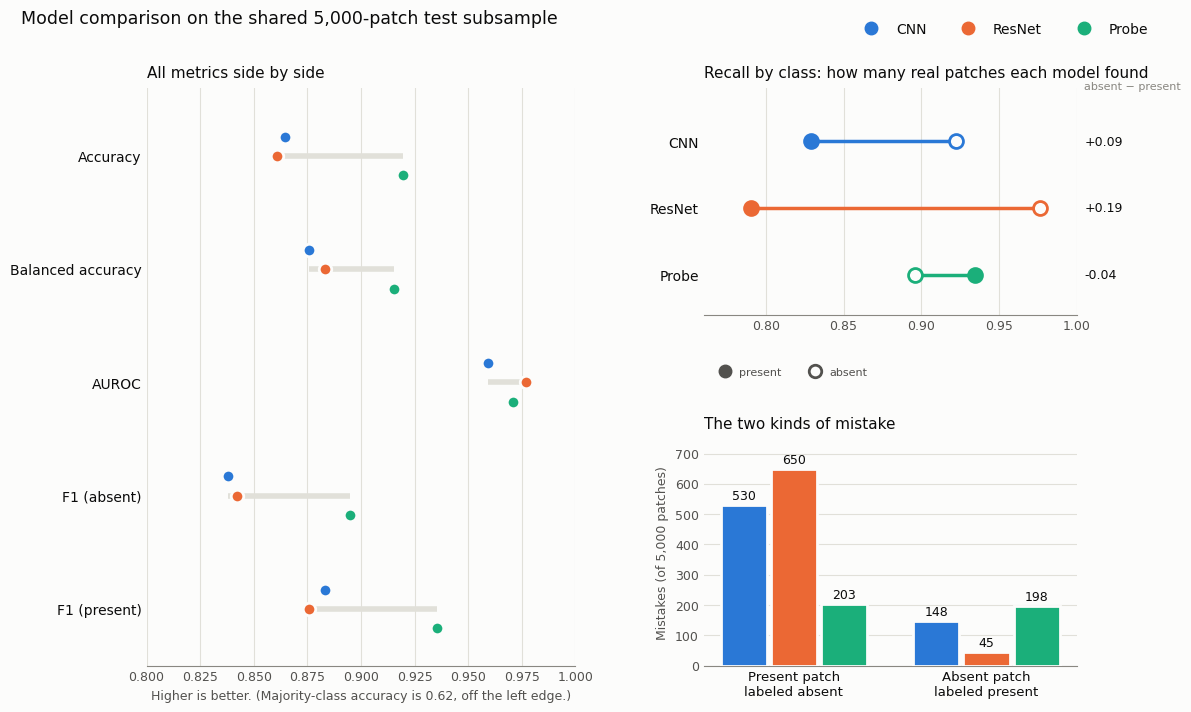

In [ ]:
from matplotlib.lines import Line2D
from sklearn.metrics import confusion_matrix

# Same fixed color per model as the previous chart
COLORS = {'CNN': '#2a78d6', 'ResNet': '#eb6834', 'Probe': '#1baf7a'}
SURFACE, INK, INK2, MUTED, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9'
models = ['CNN', 'ResNet', 'Probe']
9
def style(ax, grid='x'):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(MUTED)
    ax.tick_params(colors=INK2, length=0, labelsize=9)
    getattr(ax, f'{grid}axis').grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(12, 7.5), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, width_ratios=[1.15, 1], hspace=0.55, wspace=0.32)

# ---- Left: every metric, one row per metric, one dot per model ----
ax = fig.add_subplot(gs[:, 0])
style(ax)
metric_rows = [('accuracy', 'Accuracy'), ('balanced_acc', 'Balanced accuracy'), ('AUROC', 'AUROC'),
               ('F1_absent', 'F1 (absent)'), ('F1_present', 'F1 (present)')]
for y, (col, label) in enumerate(metric_rows):
    vals = [table.loc[m, col] for m in models]
    ax.hlines(y, min(vals), max(vals), color=GRID, lw=4, zorder=1)   # spread between best and worst
    for j, (m, v) in enumerate(zip(models, vals)):
        ax.plot(v, y + (j - 1) * 0.17, 'o', ms=9, color=COLORS[m], mec=SURFACE, mew=2, zorder=3)  # small vertical offset so close values don't hide each other
ax.set_yticks(range(len(metric_rows)))
ax.set_yticklabels([r[1] for r in metric_rows], fontsize=10, color=INK)
ax.set_ylim(len(metric_rows) - 0.5, -0.6)
ax.set_xlim(0.80, 1.0)
base = max(eval_y.mean(), 1 - eval_y.mean())
ax.set_xlabel(f"Higher is better. (Majority-class accuracy is {base:.2f}, off the left edge.)", fontsize=9, color=INK2)
ax.set_title("All metrics side by side", fontsize=11, color=INK, loc='left', pad=8)

# ---- Top right: recall on absent vs present patches (the tilt) ----
ax = fig.add_subplot(gs[0, 1])
style(ax)
for y, m in enumerate(models):
    ra, rp = table.loc[m, 'recall_absent'], table.loc[m, 'recall_present']
    ax.hlines(y, min(ra, rp), max(ra, rp), color=COLORS[m], lw=2.5, zorder=1)
    ax.plot(rp, y, 'o', ms=10, color=COLORS[m], mec=COLORS[m], mew=2, zorder=3)   # filled = present
    ax.plot(ra, y, 'o', ms=10, mfc=SURFACE, mec=COLORS[m], mew=2, zorder=3)       # hollow = absent
    ax.text(1.005, y, f"{ra - rp:+.2f}", va='center', fontsize=9, color=INK)
ax.text(1.005, -0.75, "absent \u2212 present", fontsize=8, color=MUTED, va='bottom')
ax.set_yticks(range(len(models)))
ax.set_yticklabels(models, fontsize=10, color=INK)
ax.set_ylim(len(models) - 0.4, -0.8)
ax.set_xlim(0.76, 1.0)
ax.set_xticks([0.8, 0.85, 0.9, 0.95, 1.0])
ax.set_title("Recall by class: how many real patches each model found", fontsize=11, color=INK, loc='left', pad=8)
ax.legend(handles=[Line2D([], [], marker='o', ls='', ms=9, mfc=INK2, mec=INK2, label='present'),
                   Line2D([], [], marker='o', ls='', ms=9, mfc=SURFACE, mec=INK2, mew=2, label='absent')],
          loc='lower left', fontsize=8, frameon=False, labelcolor=INK2, ncol=2, handletextpad=0.3,
          bbox_to_anchor=(0.0, -0.32))

# ---- Bottom right: the two kinds of mistake, as counts ----
ax = fig.add_subplot(gs[1, 1])
style(ax, grid='y')
errors = {}
for m in models:
    cm = confusion_matrix(eval_y, (scores[m] > 0).astype(int))
    errors[m] = (cm[1, 0], cm[0, 1])   # (present called absent, absent called present)
w = 0.26
for j, m in enumerate(models):
    for g in range(2):
        v = errors[m][g]
        ax.bar(g + (j - 1) * w, v, w * 0.92, color=COLORS[m], edgecolor=SURFACE, linewidth=2, zorder=3)
        ax.text(g + (j - 1) * w, v + 8, f"{v}", ha='center', va='bottom', fontsize=9, color=INK)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Present patch\nlabeled absent", "Absent patch\nlabeled present"], fontsize=9.5, color=INK)
ax.set_ylabel("Mistakes (of 5,000 patches)", fontsize=9, color=INK2)
ax.set_ylim(0, max(max(e) for e in errors.values()) * 1.15)
ax.set_title("The two kinds of mistake", fontsize=11, color=INK, loc='left', pad=8)

# One shared legend for model colors
fig.legend(handles=[Line2D([], [], marker='o', ls='', ms=9, color=COLORS[m], label=m) for m in models],
           loc='upper right', ncol=3, fontsize=10, frameon=False, labelcolor=INK,
           bbox_to_anchor=(0.97, 0.985))
fig.suptitle("Model comparison on the shared 5,000-patch test subsample", fontsize=12.5, color=INK,
             x=0.02, ha='left', y=0.985)
plt.show()

In [ ]:
rng = np.random.default_rng(0)
eval_groups = patient_ids[probe_test_idx]
patients = np.array(sorted(set(eval_groups)))
idx_by_patient = {p: np.where(eval_groups == p)[0] for p in patients}
names = list(scores)
boot = {n: {'accuracy': [], 'AUROC': []} for n in names}

for _ in range(2000):
    sampled = rng.choice(patients, size=len(patients), replace=True)  # resample whole patients, not patches
    idx = np.concatenate([idx_by_patient[p] for p in sampled])
    y_b = eval_y[idx]
    if y_b.min() == y_b.max():   # AUROC undefined if only one class was drawn
        continue
    for n in names:
        s_b = scores[n][idx]
        boot[n]['accuracy'].append(((s_b > 0).astype(int) == y_b).mean())
        boot[n]['AUROC'].append(roc_auc_score(y_b, s_b))

def ci(a): return np.percentile(a, [2.5, 97.5])
print(f"Bootstrap over {len(patients)} test patients, {len(boot['CNN']['accuracy'])} valid resamples\n")
for n in names:
    pt = metrics(eval_y, scores[n])
    for m in ['accuracy', 'AUROC']:
        lo, hi = ci(boot[n][m])
        print(f"{n:7s} {m:9s} {pt[m]:.4f}  95% CI [{lo:.4f}, {hi:.4f}]")

print("\nPaired differences (same resamples):")
for a, b in [('Probe', 'CNN'), ('Probe', 'ResNet'), ('ResNet', 'CNN')]:
    for m in ['accuracy', 'AUROC']:
        d = np.array(boot[a][m]) - np.array(boot[b][m])
        lo, hi = ci(d)
        print(f"{a} - {b} {m:9s} mean {d.mean():+.4f}  95% CI [{lo:+.4f}, {hi:+.4f}]  "
              f"({'excludes 0' if (lo > 0 or hi < 0) else 'includes 0'})")

Bootstrap over 10 test patients, 2000 valid resamples

CNN     accuracy  0.8644  95% CI [0.8420, 0.8867]
CNN     AUROC     0.9593  95% CI [0.9382, 0.9766]
ResNet  accuracy  0.8610  95% CI [0.8076, 0.9003]
ResNet  AUROC     0.9771  95% CI [0.9635, 0.9855]
Probe   accuracy  0.9198  95% CI [0.9033, 0.9337]
Probe   AUROC     0.9707  95% CI [0.9583, 0.9811]

Paired differences (same resamples):
Probe - CNN accuracy  mean +0.0549  95% CI [+0.0288, +0.0813]  (excludes 0)
Probe - CNN AUROC     mean +0.0112  95% CI [-0.0008, +0.0251]  (includes 0)
Probe - ResNet accuracy  mean +0.0598  95% CI [+0.0234, +0.1002]  (excludes 0)
Probe - ResNet AUROC     mean -0.0056  95% CI [-0.0118, +0.0009]  (includes 0)
ResNet - CNN accuracy  mean -0.0049  95% CI [-0.0523, +0.0267]  (includes 0)
ResNet - CNN AUROC     mean +0.0168  95% CI [+0.0010, +0.0332]  (excludes 0)


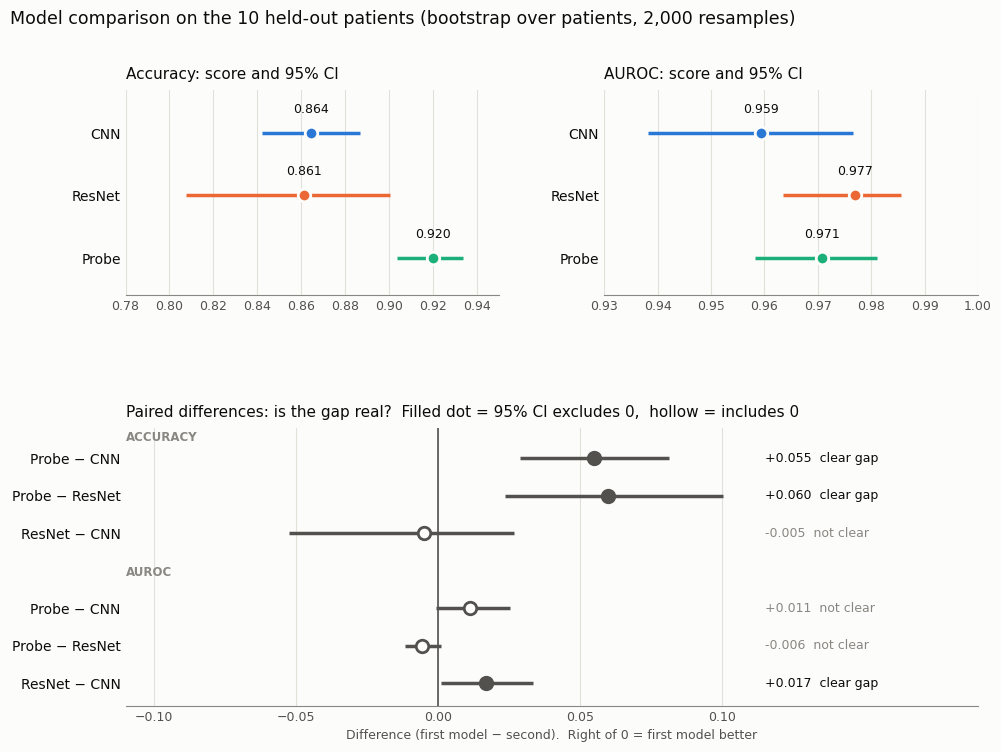

In [ ]:
# One fixed color per model (same color everywhere it appears)
COLORS = {'CNN': '#2a78d6', 'ResNet': '#eb6834', 'Probe': '#1baf7a'}
SURFACE, INK, INK2, MUTED, GRID = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9'

def style(ax):
    ax.set_facecolor(SURFACE)
    for s in ('top', 'right', 'left'):
        ax.spines[s].set_visible(False)
    ax.spines['bottom'].set_color(MUTED)
    ax.tick_params(colors=INK2, length=0, labelsize=9)
    ax.xaxis.grid(True, color=GRID, lw=0.8)
    ax.set_axisbelow(True)

fig = plt.figure(figsize=(11, 8), facecolor=SURFACE)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1.35], hspace=0.55, wspace=0.28)

# ---- Top row: each model's score with its 95% CI (dot = measured value, line = 95% CI) ----
for col, (m, xlim) in enumerate([('accuracy', (0.78, 0.95)), ('AUROC', (0.93, 1.0))]):
    ax = fig.add_subplot(gs[0, col])
    style(ax)
    for i, n in enumerate(names):
        pt = metrics(eval_y, scores[n])[m]
        lo, hi = ci(boot[n][m])
        ax.hlines(i, lo, hi, color=COLORS[n], lw=2.5)
        ax.plot(pt, i, 'o', ms=9, color=COLORS[n], mec=SURFACE, mew=2, zorder=3)
        ax.text(pt, i - 0.28, f"{pt:.3f}", ha='center', va='bottom', fontsize=9, color=INK)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels(names, fontsize=10, color=INK)
    ax.set_ylim(len(names) - 0.4, -0.7)   # first model on top
    ax.set_xlim(*xlim)
    ax.set_title(f"{m.capitalize() if m == 'accuracy' else m}: score and 95% CI", fontsize=11,
                 color=INK, loc='left', pad=8)

# ---- Bottom: paired differences (first model minus second), same resampled patients ----
ax = fig.add_subplot(gs[1, :])
style(ax)
pairs = [('Probe', 'CNN'), ('Probe', 'ResNet'), ('ResNet', 'CNN')]
rows, y = [], 0
for m in ['accuracy', 'AUROC']:
    for a, b in pairs:
        d = np.array(boot[a][m]) - np.array(boot[b][m])
        lo, hi = ci(d)
        rows.append((y, f"{a} \u2212 {b}", m, d.mean(), lo, hi, (lo > 0 or hi < 0)))
        y += 1
    y += 1  # gap between the two metric groups

XR = 0.115  # x position of the right-hand value column
for y, label, m, mean, lo, hi, real in rows:
    ax.hlines(y, lo, hi, color=INK2, lw=2.5)
    ax.plot(mean, y, 'o', ms=9, mec=INK2, mew=2,
            mfc=INK2 if real else SURFACE, zorder=3)   # filled = CI excludes 0, hollow = includes 0
    ax.text(XR, y, f"{mean:+.3f}  {'clear gap' if real else 'not clear'}", va='center',
            fontsize=9, color=INK if real else MUTED)
ax.axvline(0, color=INK2, lw=1.2, zorder=1)
ax.set_yticks([r[0] for r in rows])
ax.set_yticklabels([r[1] for r in rows], fontsize=10, color=INK)
ax.set_ylim(rows[-1][0] + 0.6, -0.8)
ax.set_xlim(-0.11, 0.19)
ax.set_xticks([-0.10, -0.05, 0, 0.05, 0.10])
ax.text(-0.11, -0.55, "ACCURACY", fontsize=8.5, color=MUTED, fontweight='bold', va='center')
ax.text(-0.11, rows[3][0] - 0.95, "AUROC", fontsize=8.5, color=MUTED, fontweight='bold', va='center')
ax.set_xlabel("Difference (first model \u2212 second).  Right of 0 = first model better", fontsize=9, color=INK2)
ax.set_title("Paired differences: is the gap real?  Filled dot = 95% CI excludes 0,  hollow = includes 0",
             fontsize=11, color=INK, loc='left', pad=8)

fig.suptitle("Model comparison on the 10 held-out patients (bootstrap over patients, 2,000 resamples)",
             fontsize=12.5, color=INK, x=0.02, ha='left', y=0.98)
plt.show()

                n  pos_rate    CNN  ResNet  Probe
patient                                          
TCGA-38-4629  374     0.714  0.877   0.642  0.866
TCGA-44-6778  406     0.833  0.850   0.810  0.892
TCGA-55-7728  426     0.516  0.899   0.908  0.915
TCGA-55-7907  580     0.643  0.843   0.897  0.921
TCGA-75-6206  459     0.301  0.935   0.974  0.922
TCGA-78-7156  559     0.651  0.882   0.891  0.948
TCGA-78-7166  597     0.564  0.881   0.894  0.955
TCGA-86-8669  541     0.654  0.871   0.902  0.913
TCGA-93-7348  451     0.783  0.825   0.796  0.894
TCGA-S2-AA1A  607     0.585  0.801   0.829  0.937


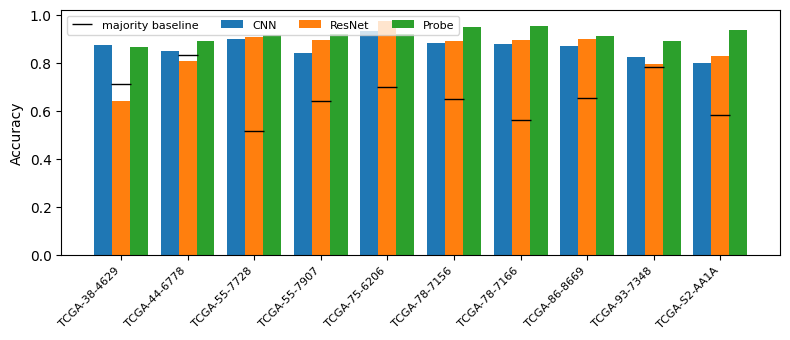

In [ ]:
rows = []
for p in patients:
    i = idx_by_patient[p]
    row = {'patient': p, 'n': len(i), 'pos_rate': eval_y[i].mean()}
    for n in names:
        row[n] = ((scores[n][i] > 0).astype(int) == eval_y[i]).mean()
    rows.append(row)
per_patient = pd.DataFrame(rows).set_index('patient')
print(per_patient.round(3))

fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(per_patient)); w = 0.27
for j, n in enumerate(names):
    ax.bar(x + (j - 1) * w, per_patient[n], w, label=n)
ax.plot(x, [max(r, 1 - r) for r in per_patient['pos_rate']], 'k_', markersize=14, label='majority baseline')
ax.set_xticks(x); ax.set_xticklabels(per_patient.index, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Accuracy'); ax.set_ylim(0, 1.02); ax.legend(fontsize=8, ncol=4)
plt.tight_layout(); plt.show()